# 01 — Exploratory Data Analysis
**CFPB Consumer Complaint Classification** (Debt collection vs Credit card)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

## 1. Load the data

In [2]:
df = pd.read_csv('../data/complaints.csv')
print('Shape:', df.shape)
df.head()

Shape: (114953, 16)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
0,2025-06-19T00:41:17.000Z,Debt collection,I do not know,False statements or representation,Attempted to collect wrong amount,# OFFICIAL CFPB COMPLAINT # # Debt Validation ...,NaN,CL Holdings LLC,NJ,07050,NaN,Web,2025-06-19T01:18:37.000Z,Closed with explanation,Yes,14152305
1,2025-06-19T00:32:04.000Z,Credit card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Card was charged for something you did not pur...,charges unauthorized {$850.00}. none of charge...,Company has responded to the consumer and the ...,SYNCHRONY FINANCIAL,IN,46205,NaN,Web,2025-06-19T00:35:53.000Z,Closed with explanation,Yes,14147007
2,2025-06-19T01:07:55.000Z,Debt collection,I do not know,Attempts to collect debt not owed,Debt is not yours,I want to stress that I did not give written p...,NaN,"EQUIFAX, INC.",TX,75154,NaN,Web,2025-06-19T01:09:45.000Z,Closed with explanation,Yes,14145666
3,2025-06-19T11:51:49.000Z,Credit card,General-purpose credit card or charge card,"Advertising and marketing, including promotion...",Didn't receive advertised or promotional terms,XX/XX/2025 I applied for an American Express c...,NaN,AMERICAN EXPRESS COMPANY,NY,127XX,NaN,Web,2025-06-19T12:16:46.000Z,Closed with explanation,Yes,14183479
4,2025-06-19T01:13:09.000Z,Debt collection,I do not know,Attempts to collect debt not owed,Debt was result of identity theft,JEFFERSON CAPITAL SYST is falsely reporting on...,NaN,CL Holdings LLC,DC,20002,NaN,Web,2025-06-19T01:15:56.000Z,Closed with explanation,Yes,14145747


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114953 entries, 0 to 114952
Data columns (total 16 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   Date received                 114953 non-null  object
 1   Product                       114953 non-null  object
 2   Sub-product                   114953 non-null  object
 3   Issue                         114953 non-null  object
 4   Sub-issue                     114905 non-null  object
 5   Consumer complaint narrative  114953 non-null  object
 6   Company public response       42791 non-null   object
 7   Company                       114953 non-null  object
 8   State                         114669 non-null  object
 9   ZIP code                      114929 non-null  object
 10  Tags                          13772 non-null   object
 11  Submitted via                 114953 non-null  object
 12  Date sent to company          114953 non-null  object
 13 

In [4]:
df.describe(include='object')

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?
count,114953,114953,114953,114953,114905,114953,42791,114953,114669,114929,13772,114953,114953,114953,114953
unique,113769,2,13,22,83,94274,10,1923,57,6792,3,1,112627,5,2
top,2025-06-26T01:30:17.000Z,Debt collection,I do not know,Attempts to collect debt not owed,Debt is not yours,There are collection accounts on my report tha...,Company has responded to the consumer and the ...,"EQUIFAX, INC.",TX,XXXXX,Servicemember,Web,2025-12-18T21:15:44.000Z,Closed with explanation,Yes
freq,3,79308,33990,37372,19298,4857,35178,6807,17679,1950,8324,114953,5,86424,112672


## 2. Null values per column

In [5]:
null_counts = df.isnull().sum().sort_values(ascending=False)
null_pct = (null_counts / len(df) * 100).round(2)

null_summary = pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct})
print(null_summary[null_summary['null_count'] > 0])

                         null_count  null_pct
Tags                         101181     88.02
Company public response       72162     62.78
State                           284      0.25
Sub-issue                        48      0.04
ZIP code                         24      0.02


## 3. Null analysis for categorical columns
For columns with nulls (Sub-product, Issue, State, Company), we'll fill with mode — no need to drop rows.

In [6]:
cat_cols_with_nulls = ['Sub-product', 'Issue', 'State', 'Company']

for col in cat_cols_with_nulls:
    n = df[col].isnull().sum()
    if n > 0:
        mode_val = df[col].mode()[0]
        print(f"{col}: {n} nulls — will fill with mode '{mode_val}'")
    else:
        print(f"{col}: no nulls")

Sub-product: no nulls
Issue: no nulls
State: 284 nulls — will fill with mode 'TX'
Company: no nulls


## 4. Top categories

In [7]:
print('=== Product ===' )
print(df['Product'].value_counts())
print()

=== Product ===
Product
Debt collection    79308
Credit card        35645
Name: count, dtype: int64



In [8]:
print('=== Sub-product (top 10) ===')
print(df['Sub-product'].value_counts().head(10))
print()

=== Sub-product (top 10) ===
Sub-product
I do not know                                 33990
General-purpose credit card or charge card    31032
Other debt                                    13743
Credit card debt                              12960
Rental debt                                    4780
Store credit card                              4613
Telecommunications debt                        4428
Auto debt                                      4054
Medical debt                                   3214
Payday loan debt                               1191
Name: count, dtype: int64



In [9]:
print('=== Issue (top 10) ===')
print(df['Issue'].value_counts().head(10))

=== Issue (top 10) ===
Issue
Attempts to collect debt not owed                      37372
Written notification about debt                        17741
False statements or representation                     10959
Problem with a purchase shown on your statement        10674
Took or threatened to take negative or legal action     6684
Other features, terms, or problems                      4254
Fees or interest                                        3952
Getting a credit card                                   3775
Communication tactics                                   3745
Closing your account                                    2760
Name: count, dtype: int64


## 5. Word count distribution of narratives

In [10]:
df['word_count'] = df['Consumer complaint narrative'].dropna().apply(lambda x: len(str(x).split()))
print(df['word_count'].describe())

count    114953.000000
mean        185.837551
std         193.125498
min           5.000000
25%          65.000000
50%         137.000000
75%         244.000000
max        5111.000000
Name: word_count, dtype: float64


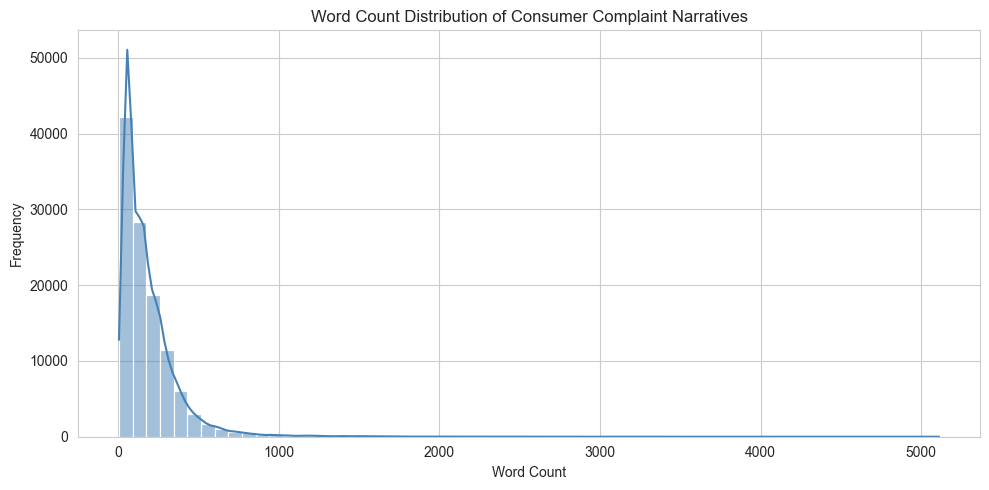

In [11]:
# histogram of word counts
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['word_count'].dropna(), bins=60, kde=True, color='steelblue', ax=ax)
ax.set_title('Word Count Distribution of Consumer Complaint Narratives')
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('../outputs/word_count_histogram.png', dpi=150)
plt.show()

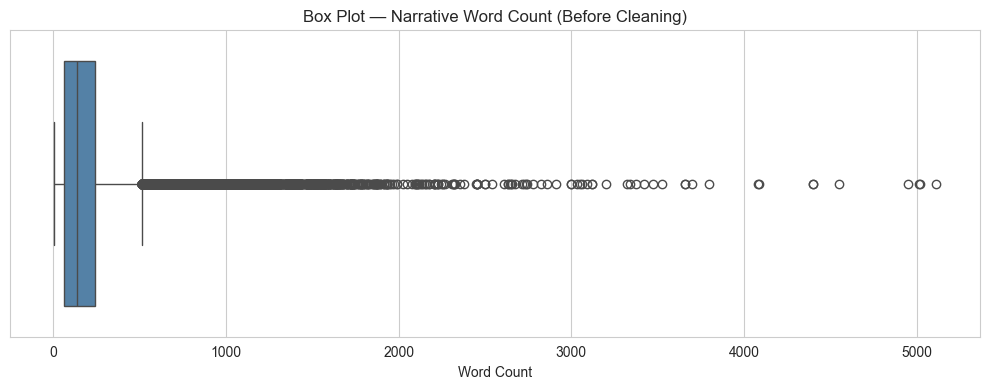

In [12]:
# box plot of word count distribution
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(x=df['word_count'].dropna(), color='steelblue', ax=ax)
ax.set_title('Box Plot — Narrative Word Count (Before Cleaning)')
ax.set_xlabel('Word Count')
plt.tight_layout()
plt.savefig('../outputs/word_count_boxplot_before.png', dpi=150)
plt.show()

## 6. Class balance check

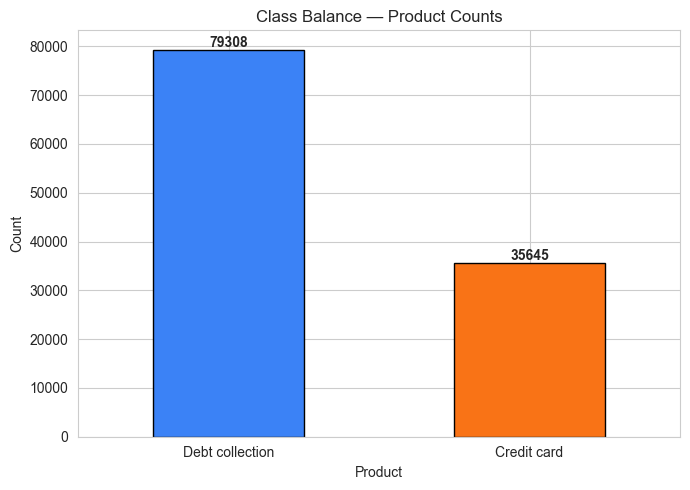

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
product_counts = df['Product'].value_counts()
colors = ['#3b82f6', '#f97316']
product_counts.plot(kind='bar', color=colors, edgecolor='black', ax=ax)
ax.set_title('Class Balance — Product Counts')
ax.set_ylabel('Count')
ax.set_xlabel('Product')

for i, v in enumerate(product_counts):
    ax.text(i, v + 500, str(v), ha='center', fontweight='bold')

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/class_balance.png', dpi=150)
plt.show()

## 7. Duplicate narratives

In [14]:
narratives = df['Consumer complaint narrative'].dropna()
dup_count = narratives.duplicated().sum()
print(f'Duplicate narratives: {dup_count} ({dup_count / len(narratives) * 100:.2f}%)')

Duplicate narratives: 20679 (17.99%)


## 8. Redacted narratives (mostly XXXX)

In [15]:
def calc_redaction_pct(text):
    words = str(text).split()
    if len(words) == 0:
        return 0
    xxxx_count = sum(1 for w in words if 'XXXX' in w.upper())
    return xxxx_count / len(words)

redaction_pcts = narratives.apply(calc_redaction_pct)
heavy_redacted = (redaction_pcts > 0.5).sum()
print(f'Narratives with >50% redacted words: {heavy_redacted}')

Narratives with >50% redacted words: 146


## 9. Observations
Summary of findings from EDA — what cleaning is needed next.

In [16]:
observations = """
========================================
  EDA OBSERVATIONS
========================================

1. DATASET SIZE
   - {total_rows:,} total rows, 16 columns.
   - Two product classes: Debt collection ({debt:,}) and Credit card ({credit:,}).

2. MISSING VALUES
   - 'Consumer complaint narrative' has significant nulls — rows without narratives
     will be dropped since text is our primary feature.
   - Sub-product, Issue, State, Company have some nulls — fill with mode.
   - Other columns (Sub-issue, Company public response, Tags, ZIP code) have nulls
     but are not needed for modeling.

3. CLASS IMBALANCE
   - Debt collection is ~2.2x more frequent than Credit card.
   - Will balance via stratified downsampling in preprocessing.

4. DUPLICATES
   - {dups:,} duplicate narratives found — will remove.

5. REDACTED TEXT
   - {redacted} narratives are >50% 'XXXX' placeholders — will remove.

6. NARRATIVE LENGTH
   - Word counts range widely; very short narratives (<20 words)
     are unlikely to contain useful signal — will filter.
   - Some extremely long narratives (1000+ words) exist but are fine to keep.

NEXT STEPS (Notebook 02):
   - Drop unused columns
   - Fill categorical nulls with mode
   - Drop null / duplicate / short / heavily-redacted narratives
   - Clean text (strip whitespace, remove markdown junk)
   - Stratified balanced sample of 8000 rows
   - Train/test split and save to /data
========================================
""".format(
    total_rows=len(df),
    debt=len(df[df['Product'] == 'Debt collection']),
    credit=len(df[df['Product'] == 'Credit card']),
    dups=dup_count,
    redacted=heavy_redacted
)

print(observations)


  EDA OBSERVATIONS

1. DATASET SIZE
   - 114,953 total rows, 16 columns.
   - Two product classes: Debt collection (79,308) and Credit card (35,645).

2. MISSING VALUES
   - 'Consumer complaint narrative' has significant nulls — rows without narratives
     will be dropped since text is our primary feature.
   - Sub-product, Issue, State, Company have some nulls — fill with mode.
   - Other columns (Sub-issue, Company public response, Tags, ZIP code) have nulls
     but are not needed for modeling.

3. CLASS IMBALANCE
   - Debt collection is ~2.2x more frequent than Credit card.
   - Will balance via stratified downsampling in preprocessing.

4. DUPLICATES
   - 20,679 duplicate narratives found — will remove.

5. REDACTED TEXT
   - 146 narratives are >50% 'XXXX' placeholders — will remove.

6. NARRATIVE LENGTH
   - Word counts range widely; very short narratives (<20 words)
     are unlikely to contain useful signal — will filter.
   - Some extremely long narratives (1000+ words) exis

In [17]:
# cleanup temp column
df.drop(columns=['word_count'], inplace=True, errors='ignore')